In [1]:
import torch

In [16]:
import torchvision

In [2]:
import torch.nn as nn

In [3]:
import torchvision.transforms as transforms

In [4]:
import matplotlib.pyplot as plt

In [5]:
#device config

In [6]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [7]:
#hyper paramter

In [8]:
input_size=784

In [9]:
hidden_size=100

In [10]:
num_classes=10

In [46]:
num_epochs=10

In [12]:
batch_size=100

In [13]:
learning_rate=.001

In [19]:
training_dataset=torchvision.datasets.MNIST(root='/data',train=True,
                                           transform=transforms.ToTensor(),download=True)

100.0%
100.0%
100.0%
100.0%


In [20]:
test_dataset=torchvision.datasets.MNIST(root='/data',train=False,
                                           transform=transforms.ToTensor(),download=True)

In [22]:
train_loader=torch.utils.data.DataLoader(dataset=training_dataset,batch_size=batch_size,shuffle=True)

In [23]:
test_loader=torch.utils.data.DataLoader(dataset=test_dataset,batch_size=batch_size,shuffle=True)

In [24]:
examples=iter(train_loader)

In [26]:
samples, labels = next(examples)

In [27]:
print(samples.shape)

torch.Size([100, 1, 28, 28])


In [28]:
print(labels.shape)

torch.Size([100])


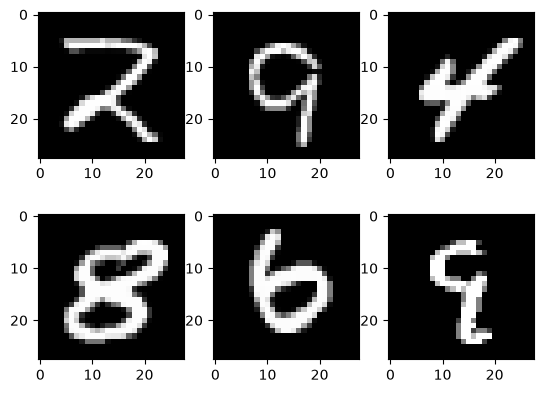

In [32]:

for i in range (6):
    plt.subplot(2,3,i+1)
    plt.imshow(samples[i][0],cmap='gray')

In [47]:
class NeuralNet(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super(NeuralNet,self).__init__()
        self.l1=nn.Linear(input_size,hidden_size)
        self.relu=nn.ReLU()
        self.l2=nn.Linear(hidden_size,num_classes)

    def forward(self,x):
        out=self.l1(x)
        out=self.relu(out)
        out=self.l2(out)
        return out


        
    

In [48]:
model=NeuralNet(input_size,hidden_size,num_classes).to(device)


In [49]:
criterion=nn.CrossEntropyLoss()

In [64]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [39]:
n_total_steps=len(train_loader)

In [53]:
for epoch in range(num_epochs):
    for i ,(images,labels) in enumerate(train_loader):
        images=images.reshape(-1,28*28).to(device)
        labels=labels.to(device)
        outputs=model(images)
        loss=criterion(outputs,labels)

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        if(i+1)%100==0:
            print(f'epoch : {epoch+1}  , step : {i+1}/{n_total_steps},loss= {loss.item()}')

epoch : 1  , step : 100/600,loss= 2.287385940551758
epoch : 1  , step : 200/600,loss= 2.2959301471710205
epoch : 1  , step : 300/600,loss= 2.2952260971069336
epoch : 1  , step : 400/600,loss= 2.3081798553466797
epoch : 1  , step : 500/600,loss= 2.2824554443359375
epoch : 1  , step : 600/600,loss= 2.2944023609161377
epoch : 2  , step : 100/600,loss= 2.2953367233276367
epoch : 2  , step : 200/600,loss= 2.306633234024048
epoch : 2  , step : 300/600,loss= 2.297292709350586
epoch : 2  , step : 400/600,loss= 2.297654867172241
epoch : 2  , step : 500/600,loss= 2.2940056324005127
epoch : 2  , step : 600/600,loss= 2.3071913719177246
epoch : 3  , step : 100/600,loss= 2.295949697494507
epoch : 3  , step : 200/600,loss= 2.28844952583313
epoch : 3  , step : 300/600,loss= 2.3011655807495117
epoch : 3  , step : 400/600,loss= 2.293933629989624
epoch : 3  , step : 500/600,loss= 2.285951614379883
epoch : 3  , step : 600/600,loss= 2.2997446060180664
epoch : 4  , step : 100/600,loss= 2.303041458129883
epo

In [51]:
with torch.no_grad():
    n_correct=0
    n_samples=0
    for images,labels in test_loader:
        images=images.reshape(-1,28*28).to(device)
        labels=labels.to(device)
        outputs=model(images)

        _,preictions=torch.max(outputs,1)
        n_samples+=labels.shape[0]
        n_correct+=(preictions==labels).sum().item()

    acc=100*n_correct/n_samples
    print(acc)

11.25


In [55]:
print(torch.bincount(preictions))

tensor([24, 12,  9,  0,  1, 45,  3,  0,  6], device='cuda:0')


In [57]:
print("Actual:")
print(labels[:20].cpu())

print("Predicted:")
print(preictions[:20].cpu())

print("Prediction distribution:")
print(torch.bincount(preictions, minlength=10).cpu())

Actual:
tensor([3, 3, 5, 0, 1, 6, 2, 6, 5, 9, 3, 2, 0, 1, 7, 6, 4, 7, 3, 3])
Predicted:
tensor([0, 5, 1, 8, 2, 5, 5, 0, 5, 6, 5, 5, 5, 1, 4, 0, 2, 5, 5, 6])
Prediction distribution:
tensor([24, 12,  9,  0,  1, 45,  3,  0,  6,  0])


In [59]:
correct = (preictions == labels).sum().item()

print("Correct:", correct)
print("Total:", labels.size(0))
print("Accuracy:", 100 * correct / labels.size(0))

Correct: 10
Total: 100
Accuracy: 10.0


In [60]:
print("Loss:", loss.item())

print("Gradient:")
print(model.l1.weight.grad.abs().mean())

print("Weights:")
print(model.l1.weight.abs().mean())

Loss: 2.2846908569335938
Gradient:
tensor(12.3276, device='cuda:0')
Weights:
tensor(0.0178, device='cuda:0', grad_fn=<MeanBackward0>)


In [61]:
images, labels = next(iter(train_loader))

print(torch.bincount(labels, minlength=10))

tensor([ 9, 13, 10, 12,  8, 10,  7,  8, 10, 13])


In [62]:
images, labels = next(iter(train_loader))

images = images.reshape(-1, 28*28).to(device)
labels = labels.to(device)

outputs = model(images)

print(outputs[:5])
print(torch.argmax(outputs, dim=1)[:20])

tensor([[ 8.0122e-02,  4.9701e-02,  6.5899e-02, -2.0860e-02, -4.7382e-02,
          9.6013e-02, -3.6065e-02, -1.3535e-01,  6.3995e-02, -1.3884e-01],
        [ 2.9039e-02,  8.5771e-03,  1.2209e-01,  6.7671e-03, -7.0238e-03,
          2.6303e-02, -4.9647e-02, -4.9639e-02, -2.1850e-02, -1.0005e-01],
        [ 7.8133e-02,  2.7952e-02,  5.5368e-02, -5.2176e-02, -9.9225e-03,
          5.3992e-02, -1.1468e-04, -7.3114e-02,  6.7529e-02, -5.3000e-02],
        [ 1.0170e-01,  3.7005e-02,  7.8737e-02, -6.0843e-02,  8.8289e-03,
          4.7617e-02,  2.2817e-02, -8.1037e-02,  3.6494e-02, -2.3061e-02],
        [ 1.8819e-02,  8.8607e-02,  2.8146e-02, -5.3867e-02,  5.3826e-02,
          1.1341e-01, -2.7332e-02, -7.3955e-02,  3.0152e-02, -1.6816e-01]],
       device='cuda:0', grad_fn=<SliceBackward0>)
tensor([5, 2, 0, 0, 5, 6, 5, 5, 1, 1, 8, 5, 0, 5, 1, 0, 2, 5, 5, 2],
       device='cuda:0')


In [63]:
# Get one batch
images, labels = next(iter(train_loader))

images = images.reshape(-1, 28*28).to(device)
labels = labels.to(device)

# Save a copy of the weights BEFORE update
old_weight = model.l1.weight.clone().detach()

# Forward
outputs = model(images)
loss = criterion(outputs, labels)

# Backward
optimizer.zero_grad()
loss.backward()

# Update
optimizer.step()

# Compare weights
new_weight = model.l1.weight.clone().detach()

print("Loss:", loss.item())
print("Weight change:", (new_weight - old_weight).abs().mean().item())

Loss: 2.2961597442626953
Weight change: 0.0


In [65]:
for epoch in range(num_epochs):

    for i, (images, labels) in enumerate(train_loader):

        images = images.reshape(-1, 28 * 28).to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            print(
                f"Epoch [{epoch+1}/{num_epochs}], "
                f"Step [{i+1}/{len(train_loader)}], "
                f"Loss: {loss.item():.4f}"
            )

Epoch [1/10], Step [100/600], Loss: 0.6458
Epoch [1/10], Step [200/600], Loss: 0.3530
Epoch [1/10], Step [300/600], Loss: 0.3097
Epoch [1/10], Step [400/600], Loss: 0.3364
Epoch [1/10], Step [500/600], Loss: 0.3726
Epoch [1/10], Step [600/600], Loss: 0.3359
Epoch [2/10], Step [100/600], Loss: 0.1631
Epoch [2/10], Step [200/600], Loss: 0.1805
Epoch [2/10], Step [300/600], Loss: 0.2034
Epoch [2/10], Step [400/600], Loss: 0.1526
Epoch [2/10], Step [500/600], Loss: 0.1120
Epoch [2/10], Step [600/600], Loss: 0.1951
Epoch [3/10], Step [100/600], Loss: 0.1092
Epoch [3/10], Step [200/600], Loss: 0.3651
Epoch [3/10], Step [300/600], Loss: 0.1612
Epoch [3/10], Step [400/600], Loss: 0.0696
Epoch [3/10], Step [500/600], Loss: 0.1498
Epoch [3/10], Step [600/600], Loss: 0.1081
Epoch [4/10], Step [100/600], Loss: 0.1251
Epoch [4/10], Step [200/600], Loss: 0.0480
Epoch [4/10], Step [300/600], Loss: 0.0831
Epoch [4/10], Step [400/600], Loss: 0.1961
Epoch [4/10], Step [500/600], Loss: 0.1130
Epoch [4/10